# Pronóstico del volumen de visitas al servicio de urgencias con suavizamiento exponencial (PROC ESM)


## Resumen ejecutivo

Un sistema hospitalario de tamaño medio necesita un pronóstico a un año del volumen mensual de visitas al servicio de urgencias (ED) para planificar la dotación de personal de enfermería y la capacidad de camas antes del pico respiratorio invernal. Este notebook construye un censo mensual sintético de urgencias de cuatro años (48 meses, ene 2021 - dic 2024) y ajusta un modelo estacional multiplicativo de Winters con **PROC ESM** para producir un pronóstico a 12 meses con intervalos de predicción del 95%.

El modelo ajustado captura bien la serie: dentro de la muestra el **RMSE es de unas 320 visitas** y el **MAPE es del 4,16%**, de modo que el error mensual típico está por debajo del 5% del volumen. El pronóstico proyecta la forma estacional habitual hacia 2025 - un pico de diciembre a febrero cercano a **7.300-7.800 visitas/mes** y un valle de finales de verano cercano a **5.800-5.900** - con bandas de predicción que se ensanchan a medida que se extiende el horizonte. Esos números, y los pesos de suavizamiento que los sustentan, se leen directamente de los conjuntos de datos de salida del procedimiento que figuran a continuación.


## Fuentes de datos

| Conjunto de datos | Filas | Grano | Variables clave | Descripción |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Una fila por mes calendario, ene 2021 - dic 2024 | `month` (fecha SAS mensual), `ed_visits` (recuento entero mensual de visitas a urgencias) | Volumen mensual sintético de visitas al servicio de urgencias para un sistema hospitalario de tamaño medio. Generado con una tendencia de crecimiento al alza (~3% anual), un ciclo estacional multiplicativo que alcanza su pico en la temporada respiratoria invernal (dic-feb) y desciende a finales de verano, más ruido log-normal para que la amplitud estacional escale con el nivel creciente. |


# Pronóstico del volumen de visitas al servicio de urgencias con PROC ESM

Los planificadores de capacidad necesitan saber cuántas visitas a urgencias esperar cada mes para poder programar al personal de enfermería, reservar camas flexibles y preparar los suministros respiratorios antes del pico invernal. El volumen de urgencias es una serie temporal estacional de manual: crece lentamente año tras año, alcanza su pico durante la temporada respiratoria de diciembre a febrero y decae a finales de verano, y el tamaño de la oscilación estacional crece a medida que crece el volumen base. Esa estructura estacional multiplicativa es exactamente lo que el método multiplicativo de Winters de **PROC ESM** está diseñado para capturar.

En este notebook:

1. Generamos un censo mensual realista de urgencias de cuatro años con tendencia, estacionalidad multiplicativa y ruido.
2. Visualizamos la serie para confirmar su estructura estacional multiplicativa.
3. Ajustamos un modelo multiplicativo de Winters con PROC ESM y leemos sus pesos de suavizamiento y estadísticos de ajuste de los conjuntos de datos de salida.
4. Producimos un pronóstico a 12 meses vista con intervalos de predicción del 95% e interpretamos las implicaciones operativas.


## Paso 1 - Generar el censo mensual sintético de urgencias

Construimos 48 observaciones mensuales desde enero de 2021 hasta diciembre de 2024. El volumen esperado de cada mes es un nivel base que crece alrededor del 3% anual, multiplicado por un índice estacional (más alto en pleno invierno, más bajo a finales de verano), y luego perturbado por ruido log-normal para que la variación aleatoria escale con el nivel. `intnx` avanza la fecha alineada al mes un periodo por fila, y `streaminit` hace reproducible la extracción.


In [1]:
DATOS ed_census;
    LLAMAR streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    ARREGLO seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    FORMATO month yymmn6.;
    HACER i = 1 HASTA 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        SALIDA;
    END;
    MANTENER month ed_visits;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=ed_census(obs=14) noobs ETIQUETA;
    ETIQUETA month = 'Mes' ed_visits = 'Visitas a urgencias';
    TÍTULO 'Primeros 14 meses del volumen sintético de visitas a urgencias';
EJECUTAR;


                             Primeros 14 meses del volumen sintético de visitas a urgencias                             

   Mes  Visitas a urgencias
202101                 7103
202102                 6835
202103                 6668
202104                 5611
202105                 5816
202106                 5383
202107                 5586
202108                 5283
202109                 5161
202110                 6109
202111                 6451
202112                 6730
202201                 6847
202202                 7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Los primeros meses confirman el diseño: el volumen abre cerca de 7.100 en el pico de enero de 2021, cae durante la primavera y el verano hasta su valle de agosto-septiembre, y luego vuelve a subir hacia el siguiente invierno. Para enero de 2022 el pico ha subido hasta unos 6.800-7.200, reflejando el crecimiento anual del ~3% superpuesto al ciclo estacional.


## Paso 2 - Visualizar la serie

Antes de modelar, graficamos la serie en bruto para confirmar la estructura que esperamos: una suave tendencia al alza con un pico anual repetido cada invierno cuya amplitud se ensancha con el tiempo. Una oscilación estacional que se ensancha es la firma de un proceso estacional *multiplicativo* y nos indica qué modelo ESM elegir.


                             Primeros 14 meses del volumen sintético de visitas a urgencias                             




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


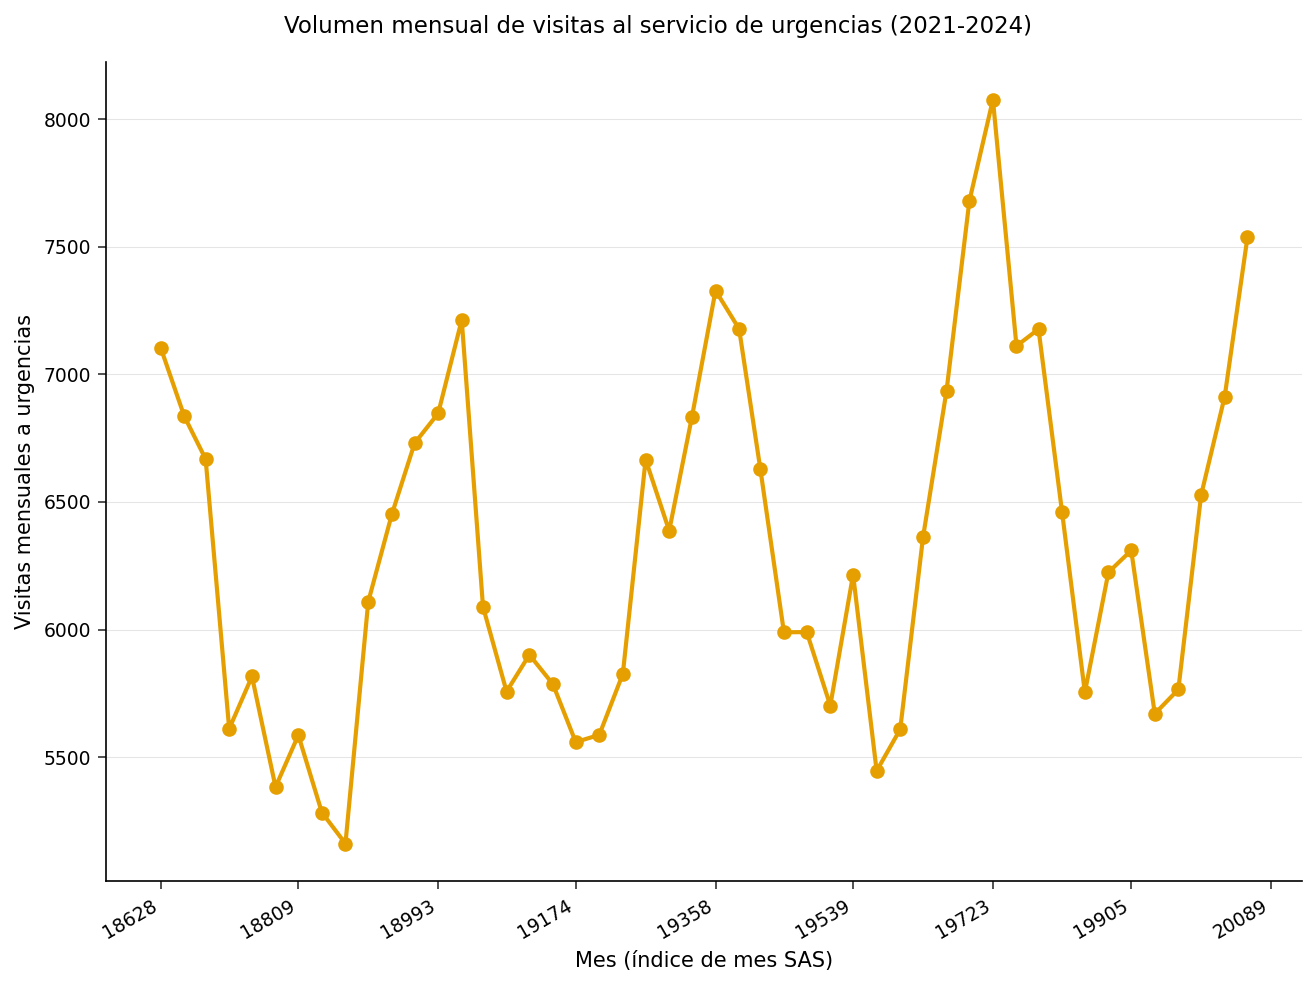

In [2]:
PROCEDIMIENTO SGPLOT DATOS=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ETIQUETA='Mes (índice de mes SAS)';
    YAXIS ETIQUETA='Visitas mensuales a urgencias' grid;
    TÍTULO 'Volumen mensual de visitas al servicio de urgencias (2021-2024)';
EJECUTAR;


El gráfico muestra cuatro ciclos anuales nítidos. Cada pico invernal se sitúa un poco más alto que el anterior, subiendo de aproximadamente 7.100 en 2021 a cerca de 8.100 en el pico de 2024, mientras que los valles de verano suben de forma más modesta - la oscilación estacional crece con el nivel. Esa amplitud creciente es el sello distintivo de la estacionalidad multiplicativa y justifica `MODEL=WINTERS` (Winters multiplicativo) en el siguiente paso.


## Paso 3 - Ajustar el modelo multiplicativo de Winters

Ajustamos el suavizamiento estacional multiplicativo de Winters sobre el historial completo de 48 meses. La sentencia `ID` declara `month` como el índice temporal con un intervalo `MONTH`, y la sentencia `FORECAST` solicita `MODEL=WINTERS` con `LEAD=12` para proyectar un año vista. Capturamos tres conjuntos de datos de salida:

- `OUT=` - la serie histórica con el pronóstico añadido (una columna `ed_visits`), con el ID temporal extendido sobre el horizonte de pronóstico - ideal para graficar.
- `OUTFOR=` - los componentes del pronóstico por periodo: pronóstico puntual (`PREDICT`) y los límites de predicción inferior/superior.
- `OUTSUM=` - los estadísticos de ajuste del modelo (RMSE, MAE, MAPE, AIC) y los pesos de suavizamiento, en una única fila resumen.

`ALPHA=0.05` produce límites de predicción del 95%, apropiados para los márgenes de riesgo de la planificación de capacidad. `PRINT=(STATISTICS)` reproduce los estadísticos de ajuste y los pesos de suavizamiento en el listado.


In [3]:
PROCEDIMIENTO esm DATOS=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        IMPRIMIR=(statistics);
    id month interval=month;
    forecast ed_visits / MODELO=winters ALPHA=0.05;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=esm_summary noobs ETIQUETA;
    ETIQUETA rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Nivel (alfa)' beta='Tendencia (beta)' gamma='Estación (gamma)';
    VAR rmse mae mape ALPHA beta gamma;
    TÍTULO 'Estadísticos de ajuste de Winters y pesos de suavizamiento';
EJECUTAR;


                             Primeros 14 meses del volumen sintético de visitas a urgencias                             


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                               Estadísticos de ajuste de Winters y pesos de suavizamiento                               

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


La fila de `OUTSUM=` y los estadísticos impresos coinciden: el ajuste multiplicativo de Winters logra dentro de la muestra un **RMSE de 320,4 visitas**, un **MAE de 264,4** y un **MAPE del 4,16%** - un error mensual típico muy por debajo del 5% del volumen, cómodamente preciso para la planificación de personal. Los pesos de suavizamiento son **alpha = 0,30** (nivel), **beta = 0,10** (tendencia) y **gamma = 0,10** (estación). El peso moderado del nivel permite que la base derive al alza con el crecimiento de la población de pacientes, mientras que los pequeños pesos de tendencia y estación reflejan que la tasa de crecimiento y la forma del pico invernal son estables año tras año y no deben sobrerreaccionar de mes a mes.

> Nota: estos son estadísticos de ajuste *dentro de la muestra* calculados sobre la muestra de estimación, no sobre un conjunto de validación fuera de muestra. Cuantifican con qué precisión el modelo sigue el historial sobre el que se ajustó.


## Paso 4 - Ensamblar y tabular el pronóstico a 12 meses

El conjunto de datos `OUTFOR=` contiene el pronóstico puntual y los límites de predicción para cada periodo, mientras que el conjunto de datos `OUT=` lleva el ID temporal extendido limpiamente sobre el horizonte de pronóstico. Alineamos ambos por orden de observación para adjuntar las fechas de pronóstico a los límites de predicción, y luego conservamos solo los 12 meses de pronóstico. Estos son los números sobre los que actuaría un comité de dotación de personal.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
DATOS out_idx;
    ESTABLECER ed_with_forecast;
    row = _n_;
    RENOMBRAR month = fdate ed_visits = series_value;
EJECUTAR;

DATOS for_idx;
    ESTABLECER esm_forecast;
    row = _n_;
    RENOMBRAR ed_visits = observed;
    MANTENER row observed predict LOWER UPPER;
EJECUTAR;

DATOS forecast_path;
    COMBINAR out_idx for_idx;
    POR row;
    FORMATO fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
EJECUTAR;

DATOS forecast_horizon;
    ESTABLECER forecast_path;
    DONDE observed = .;   /* forecast months only (no observed value) */
    MANTENER fdate predict LOWER UPPER;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=forecast_horizon noobs ETIQUETA;
    ETIQUETA fdate   = 'Mes'
          predict = 'Visitas pronosticadas'
          LOWER   = 'Inferior 95%'
          UPPER   = 'Superior 95%';
    TÍTULO 'Pronóstico a 12 meses de visitas a urgencias con límites de predicción del 95%';
EJECUTAR;


                     Pronóstico a 12 meses de visitas a urgencias con límites de predicción del 95%                     

   Mes  Visitas pronosticadas  Inferior 95%  Superior 95%
202501                  7,822         7,194         8,450
202502                  7,539         6,651         8,427
202503                  7,292         6,204         8,380
202504                  6,263         5,007         7,519
202505                  6,397         4,992         7,801
202506                  6,039         4,501         7,578
202507                  6,236         4,574         7,897
202508                  5,867         4,091         7,644
202509                  5,802         3,918         7,686
202510                  6,804         4,818         8,790
202511                  7,173         5,090         9,256
202512                  7,567         5,391         9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


El pronóstico proyecta la firma estacional hacia 2025. El modelo proyecta el pico de enero de 2025 en unas **7.822 visitas** (intervalo del 95% 7.194-8.450), se atenúa durante la primavera, toca fondo en el valle de finales de verano cerca de **5.802** en septiembre (intervalo 3.918-7.686), y luego se recupera hasta un pico de diciembre de aproximadamente **7.567** (intervalo 5.391-9.742). La banda de predicción se ensancha de forma constante con el horizonte - el intervalo del próximo mes abarca unas +/-630 visitas, mientras que el del próximo diciembre abarca más de +/-2.000 - un recordatorio directo de que los planes a corto plazo son mucho más firmes que los de fin de año.


## Paso 5 - Graficar el historial más el pronóstico

Por último, superponemos el pronóstico sobre el historial observado para que los planificadores puedan ver el pico invernal proyectado y la banda de incertidumbre que se ensancha a medida que se extiende el horizonte. Dividimos la serie alineada `forecast_path` en el historial **observado** (línea continua) y el **pronóstico a 12 meses** (línea discontinua) para que el traspaso quede claro, y dibujamos la banda de predicción del 95% por debajo. El eje x es el índice de fecha SAS mensual, que va de izquierda a derecha desde ene 2021 hasta dic 2025.


                     Pronóstico a 12 meses de visitas a urgencias con límites de predicción del 95%                     




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


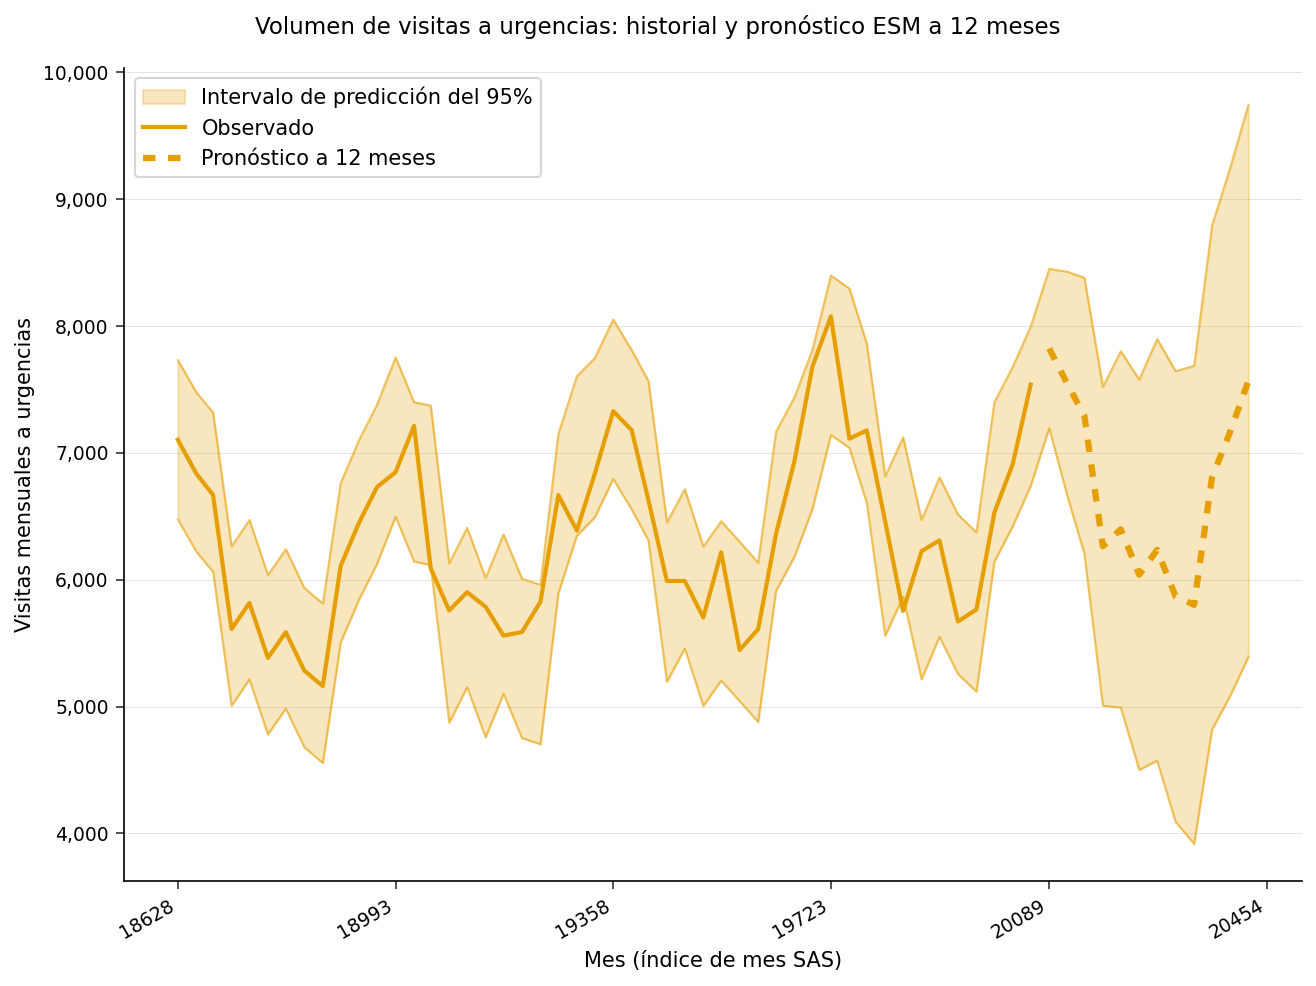

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
DATOS forecast_plot;
    ESTABLECER forecast_path;
    SI observed = . ENTONCES fc_only = predict;   /* future months only */
    SINO fc_only = .;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='Intervalo de predicción del 95%' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Observado';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='Pronóstico a 12 meses';
    XAXIS ETIQUETA='Mes (índice de mes SAS)';
    YAXIS ETIQUETA='Visitas mensuales a urgencias' grid;
    TÍTULO 'Volumen de visitas a urgencias: historial y pronóstico ESM a 12 meses';
EJECUTAR;


## Interpretación de los resultados

El modelo multiplicativo de Winters descompone el volumen de urgencias en un **nivel** que asciende lentamente, una **tendencia** casi plana y un patrón **estacional** estable. Los pesos de suavizamiento leídos de `OUTSUM=` cuentan la historia: un peso de nivel moderado (alpha = 0,30) permite que la base derive al alza con el crecimiento de la población de pacientes, mientras que los pequeños pesos de tendencia y estación (beta = gamma = 0,10) reflejan que la tasa de crecimiento y la forma del pico invernal son muy estables año tras año y no deben sobrerreaccionar de mes a mes.

Los **estadísticos de ajuste** confirman que el modelo sigue bien el historial: un RMSE de unas 320 visitas y un MAPE del 4,16% significan que el error mensual típico está por debajo del 5% del volumen. Operativamente, la **tabla de pronóstico y el gráfico de banda** cuantifican el pico de diciembre a febrero hacia el que debe dotarse de personal el servicio de urgencias - aproximadamente 7.300-7.800 visitas en los meses de invierno - y los límites de predicción del 95% definen un rango de capacidad prudente: planifique la dotación de personal básica al pronóstico puntual, y disponga por adelantado la cobertura flexible y las camas de refuerzo hacia el límite superior. El intervalo se ensancha con el horizonte, por lo que el plan del próximo mes es mucho más firme que el del próximo diciembre y debe actualizarse a medida que lleguen nuevos datos reales.

**Extensiones:** compare `MODEL=ADDWINTERS` (estacionalidad aditiva) frente al ajuste multiplicativo para confirmar la elección multiplicativa; aplique `TRANSFORM=LOG` para imponer la positividad y estabilizar la varianza; o añada una sentencia `BY` para pronosticar múltiples sedes hospitalarias en una sola llamada a PROC ESM.
